Training


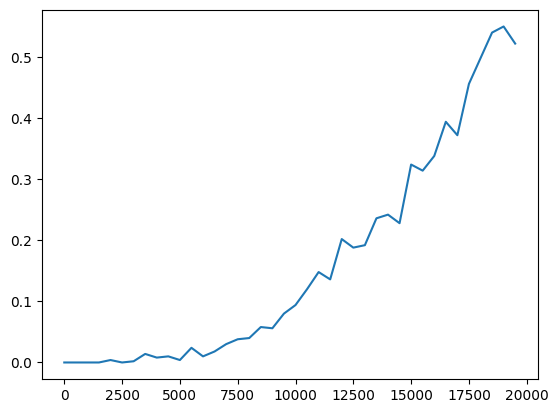

Testing


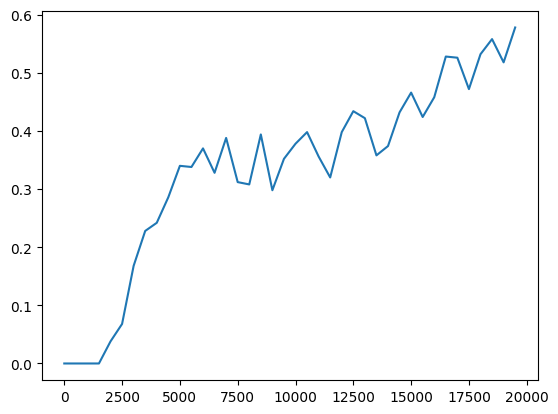

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make('FrozenLake-v1', desc=None, map_name="8x8", is_slippery=True, render_mode="rgb_array")

epsilon = 1
q_table = np.zeros((env.observation_space.n, env.action_space.n))
step_size = 0.2
discount = 0.95
episodes = 20000
found = -1
test = []
train = []

def show_ep():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

for ep in range(episodes):
    done = False
    if found>-1:
        epsilon -= (2/(episodes-found))*epsilon
    obs, info = env.reset()
    step = 0

    while not done:
        step += 1
        last_state = obs

        action = (env.action_space.sample() if np.random.rand()<epsilon else np.argmax(q_table[obs]))
        obs, reward, terminated, truncated, info = env.step(action)
        done = truncated or terminated

        if done:
            train.append(reward)
            if reward>0:
                found = ep
            #show_ep()
            #print(ep,step,reward)

        q_table[last_state][action] += step_size* (reward + discount*np.max(q_table[obs]) - q_table[last_state][action])

    obs, info = env.reset()
    done = False
    while not done:
        obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
        done = truncated or terminated
        if done:
            test.append(reward)

print('Training')
window = 500
x = range(0,episodes,window)
avg_train = [float(np.mean(train[i:i+window])) for i in x]
plt.plot(x,avg_train)
plt.show()

print('Testing')
avg_test = [float(np.mean(test[i:i+window])) for i in x]
plt.plot(x,avg_test)
plt.show()

#print(q_table)

Training


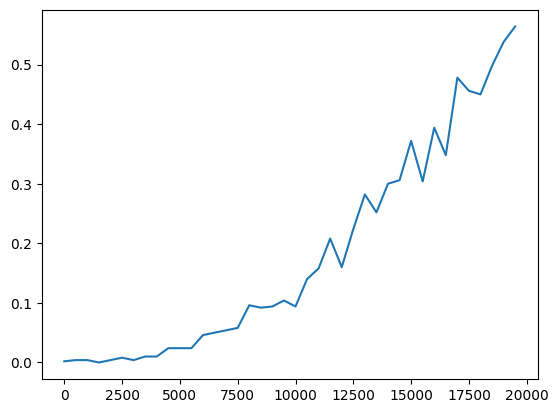

Testing


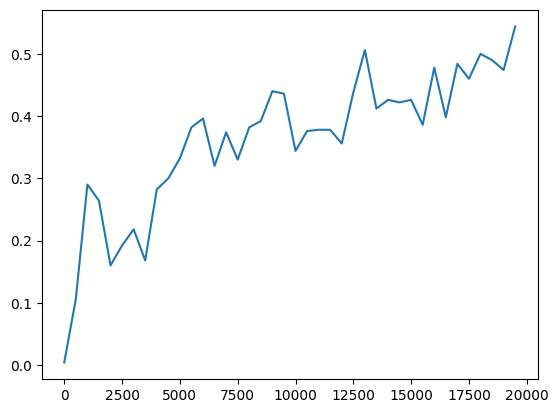

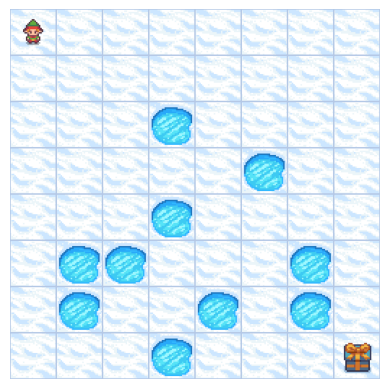

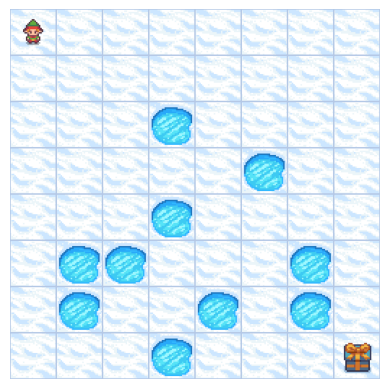

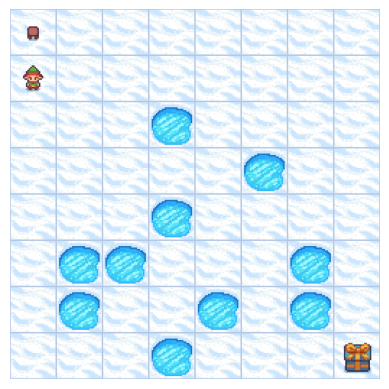

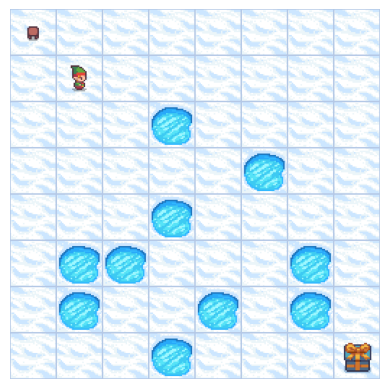

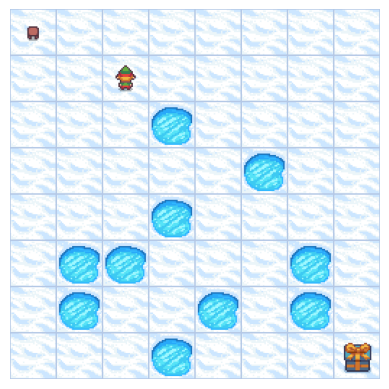

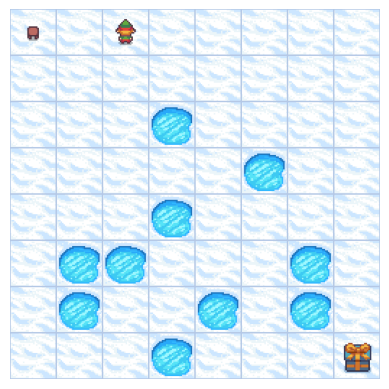

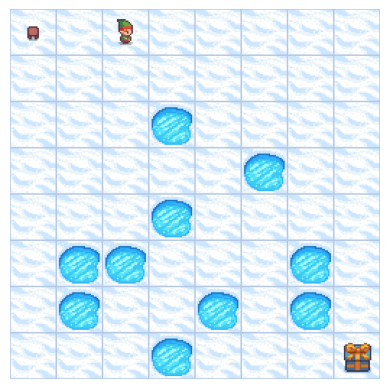

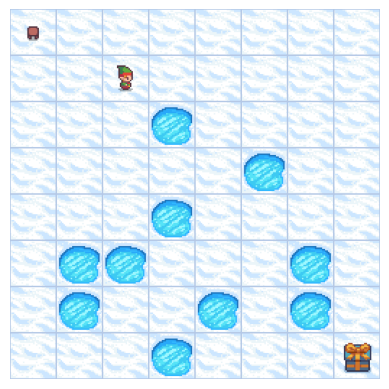

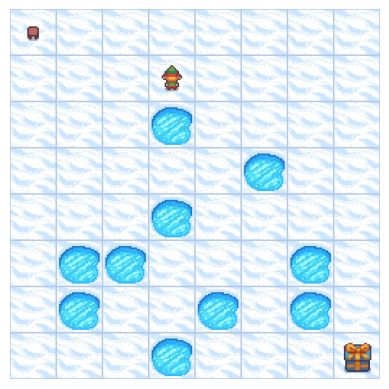

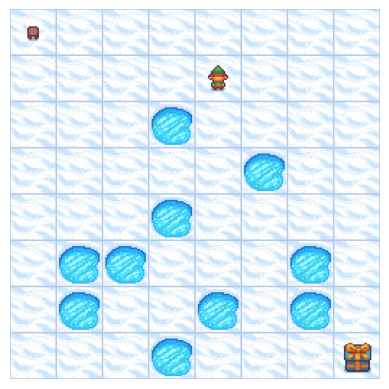

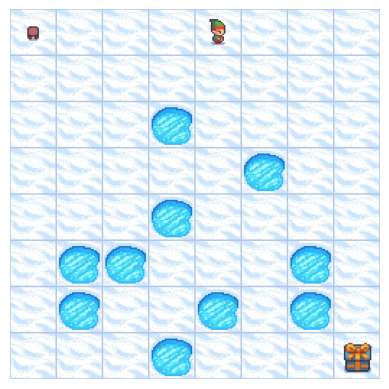

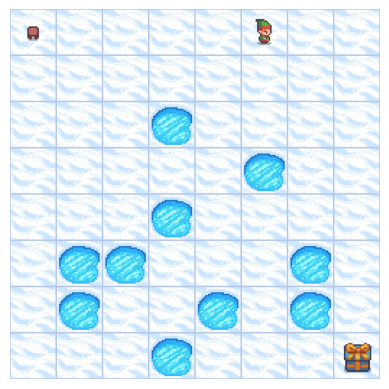

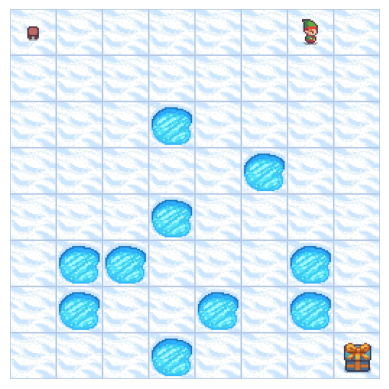

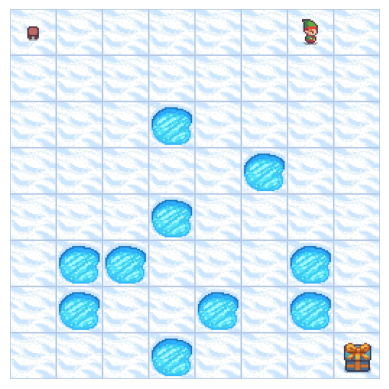

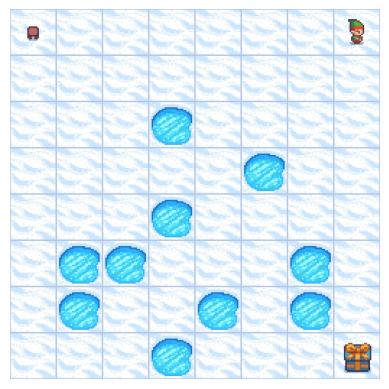

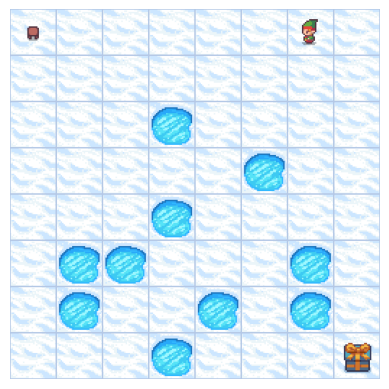

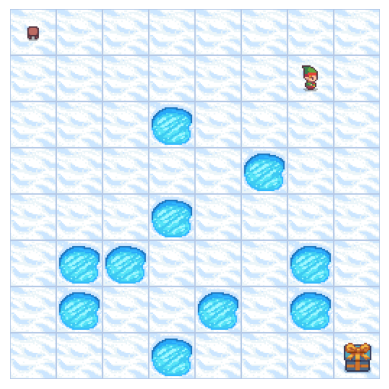

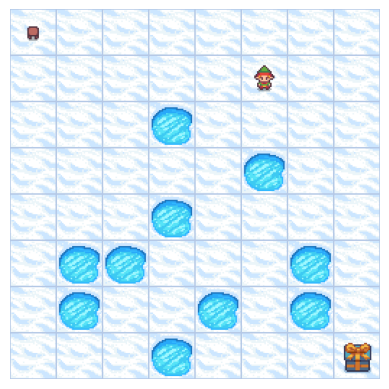

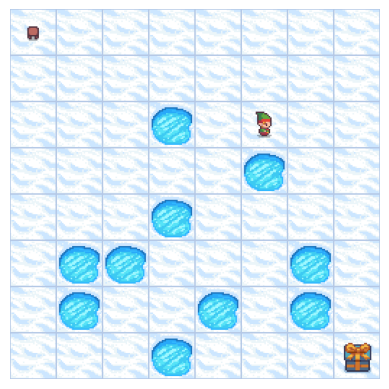

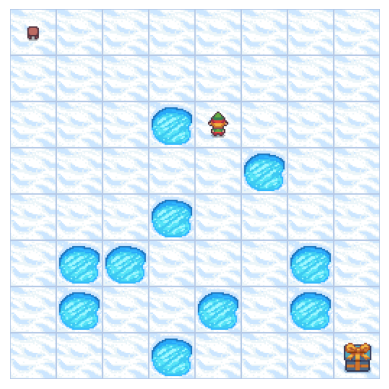

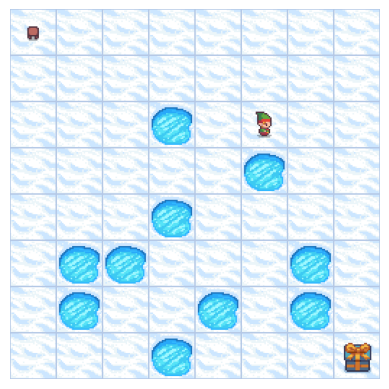

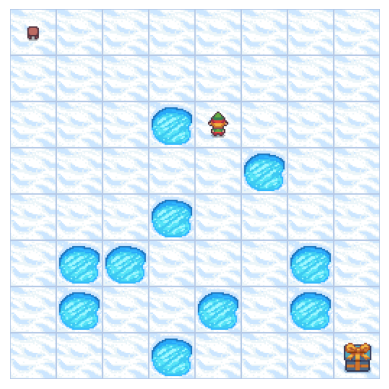

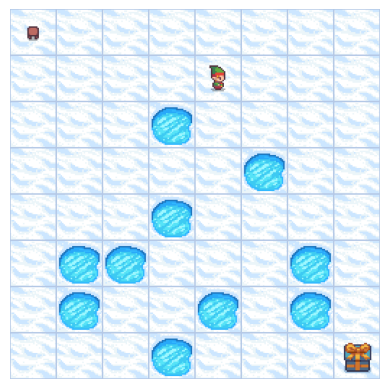

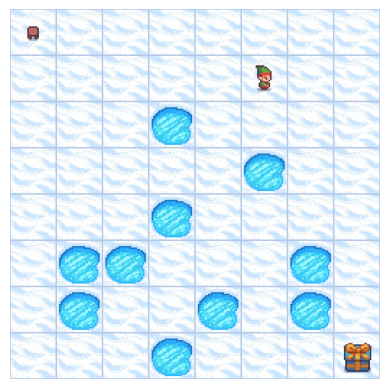

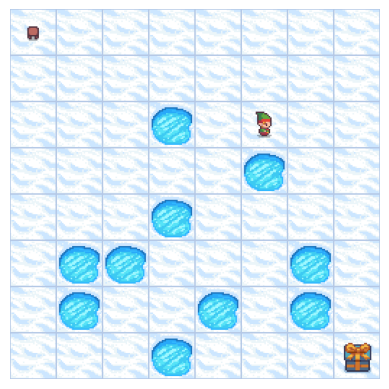

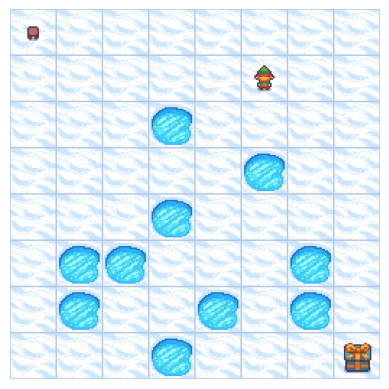

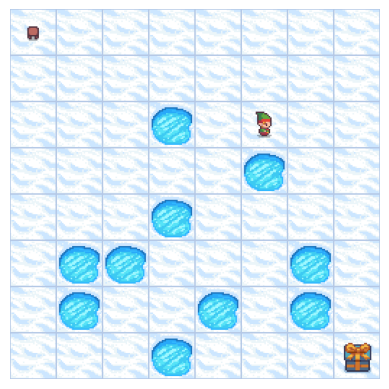

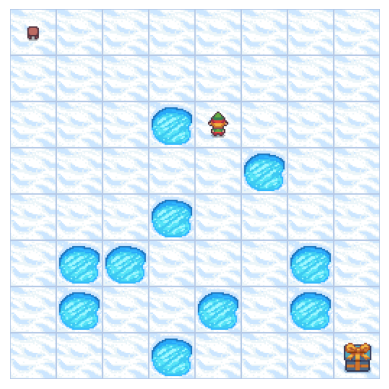

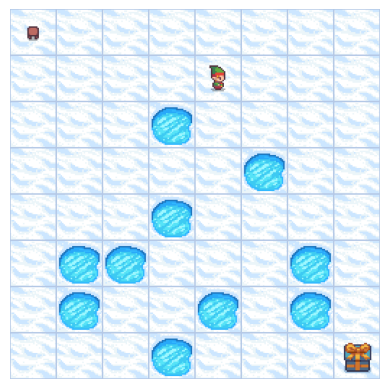

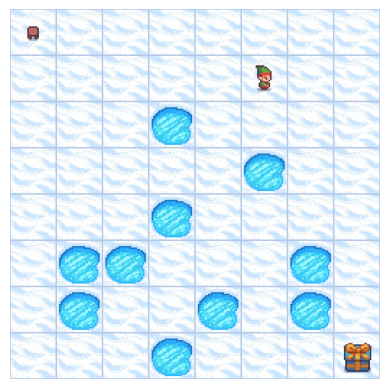

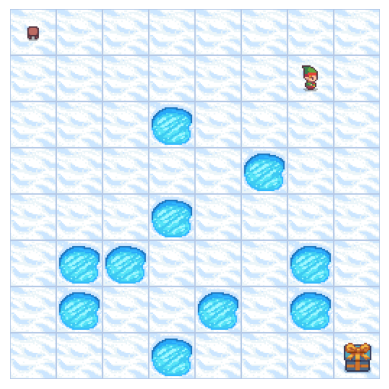

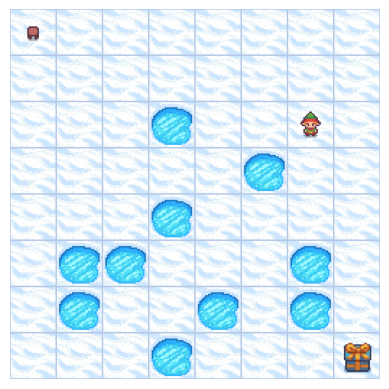

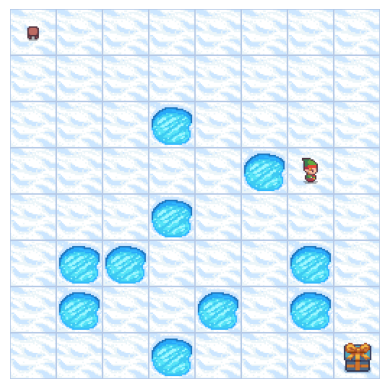

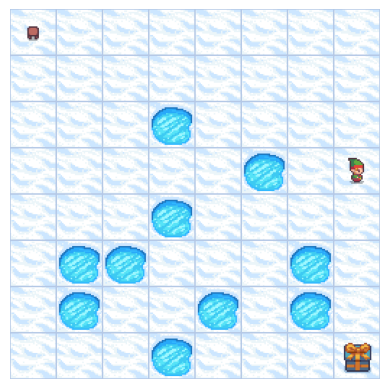

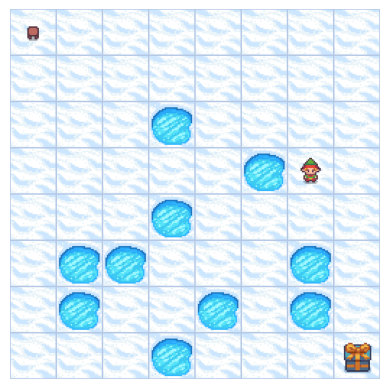

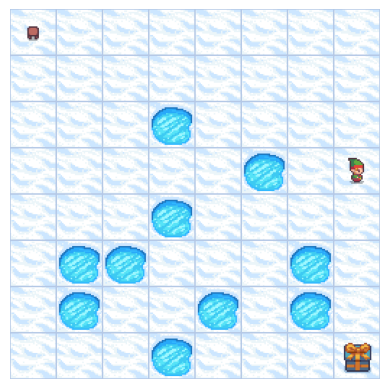

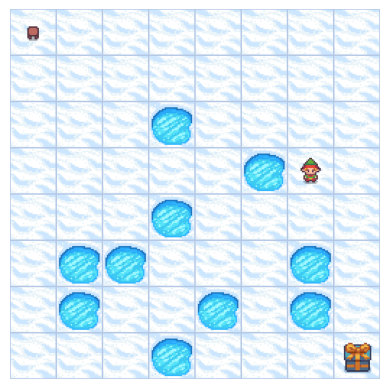

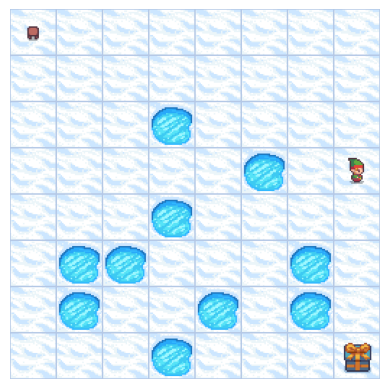

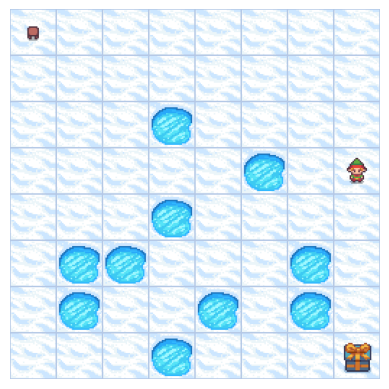

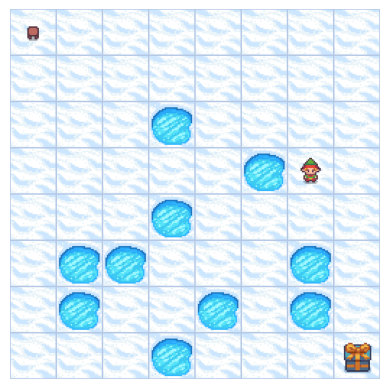

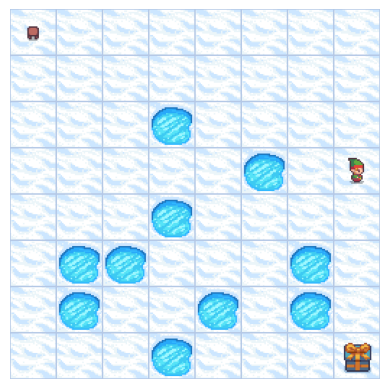

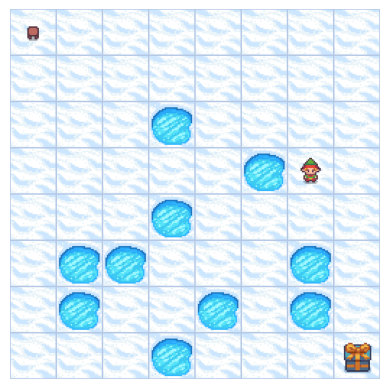

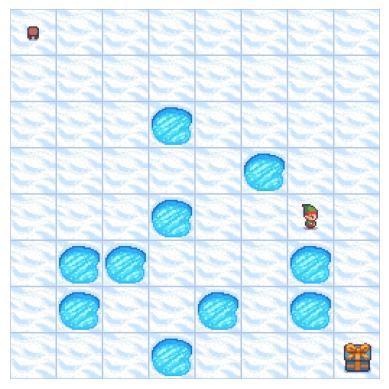

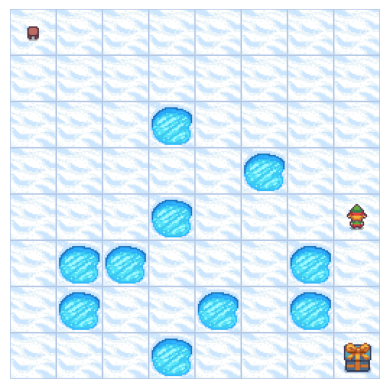

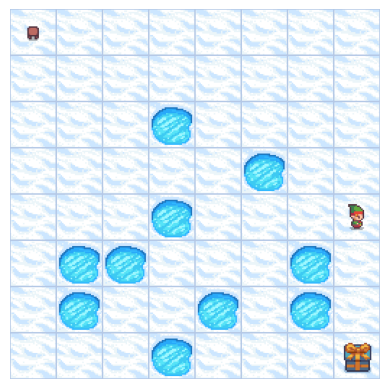

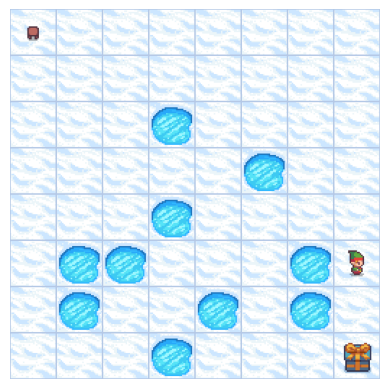

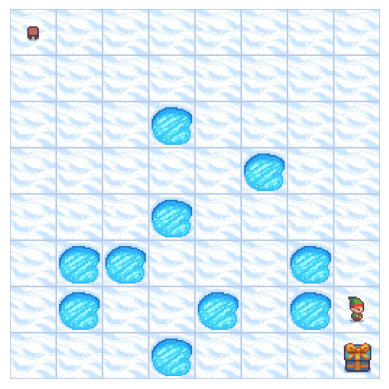

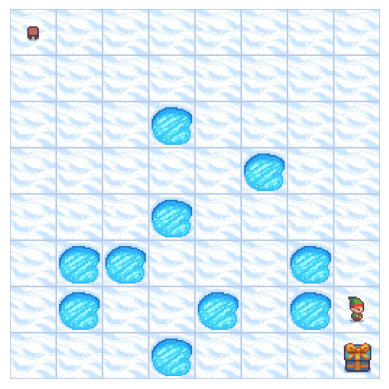

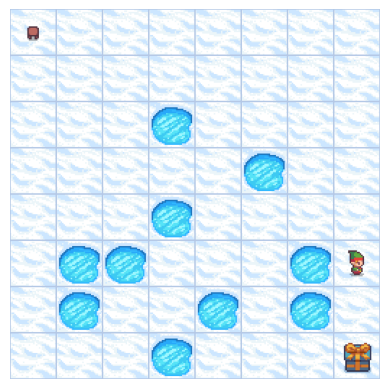

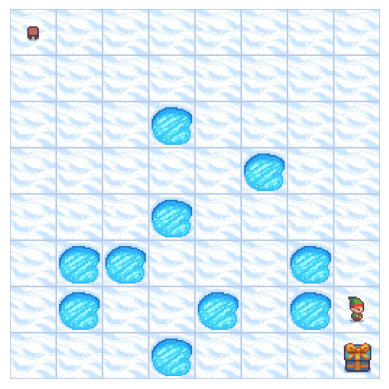

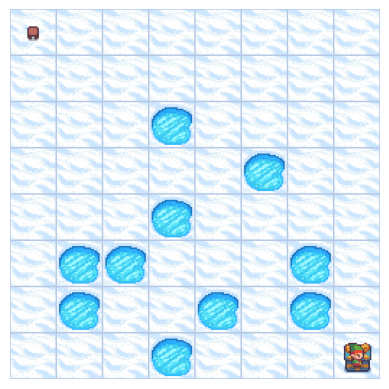

[[3.04695291e-02 4.71840916e-02 3.19377457e-02 3.19851959e-02]
 [3.62327417e-02 3.61624108e-02 5.65901863e-02 4.04192421e-02]
 [4.24927774e-02 4.96706923e-02 6.74323287e-02 4.21904886e-02]
 [5.10328700e-02 6.07784237e-02 7.69619377e-02 5.15958121e-02]
 [6.57893174e-02 6.85043024e-02 1.00515002e-01 6.23476390e-02]
 [7.83563917e-02 7.80971436e-02 1.13793336e-01 7.90906308e-02]
 [8.78172771e-02 8.56771180e-02 1.31526392e-01 8.88671889e-02]
 [1.32684953e-01 9.32295499e-02 1.03144849e-01 9.24230509e-02]
 [2.94666230e-02 3.00995108e-02 4.06396358e-02 3.00684914e-02]
 [3.20163269e-02 3.24601577e-02 3.29200978e-02 4.75931145e-02]
 [3.91654466e-02 3.67946483e-02 3.73426812e-02 5.98090903e-02]
 [3.64752077e-02 4.23135139e-02 1.67337736e-02 7.01246761e-02]
 [6.04372775e-02 6.60067252e-02 9.14876678e-02 6.51464159e-02]
 [7.47503827e-02 7.39289199e-02 1.11840611e-01 7.40868364e-02]
 [9.21034910e-02 1.56328304e-01 1.04091180e-01 9.31083119e-02]
 [1.08928999e-01 1.88332050e-01 1.03806262e-01 1.002751

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make('FrozenLake-v1', desc=None, map_name="8x8", is_slippery=True, render_mode="rgb_array")

epsilon = 1
q_table = np.zeros((env.observation_space.n, env.action_space.n))
step_size = 0.2
discount = 0.95
episodes = 20000
found = -1
test = []
train = []

def show_ep():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

for ep in range(episodes):
    done = False
    if found>-1:
        epsilon -= (2/(episodes-found))*epsilon
    obs, info = env.reset()
    step = 0

    while not done:
        step += 1
        last_state = obs

        action = (env.action_space.sample() if np.random.rand()<epsilon else np.argmax(q_table[obs]))
        obs, reward, terminated, truncated, info = env.step(action)
        done = truncated or terminated

        if done:
            train.append(reward)
            if reward>0:
                found = ep
            #show_ep()
            #print(ep,step,reward)

        q_table[last_state][action] += step_size* (reward + discount*np.max(q_table[obs]) - q_table[last_state][action])

    obs, info = env.reset()
    done = False
    while not done:
        obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
        done = truncated or terminated
        if done:
            test.append(reward)

print('Training')
window = 500
x = range(0,episodes,window)
avg_train = [float(np.mean(train[i:i+window])) for i in x]
plt.plot(x,avg_train)
plt.show()

print('Testing')
avg_test = [float(np.mean(test[i:i+window])) for i in x]
plt.plot(x,avg_test)
plt.show()

done = False
obs, info = env.reset()
while not done:
    obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
    done = truncated or terminated
    show_ep()

print(q_table)